<a href="https://colab.research.google.com/github/MichaelPE16/DATAANALYST_001/blob/main/EjerciciosD_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Practicando Pandas Primero pasos

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.DataFrame([1, 5, 4, 3, 6, 8, 6, None, 4])
df

,0
0,1.0
1,5.0
2,4.0
3,3.0
4,6.0
5,8.0
6,6.0
7,NaN
8,4.0


In [ ]:
df.dropna(inplace=True)
df

,0
0,1.0
1,5.0
2,4.0
3,3.0
4,6.0
5,8.0
6,6.0
8,4.0


In [ ]:
dict1 = {
    'nombre': [
        'Michael', "Carla", "Alan", 'Axel'
    ],
    'Apellidos': [
        'Pacheco', 'Alcantara', 'Rodriguez', 'Martinez'
    ],
    'Edad': [
        20, 22, 32, 12
    ],
    "Puesto": [
        'Data Engineer', 'Cloud Security Specialist', 'Data Scientist', 'Data Analyst'
    ]
}
dataset = pd.DataFrame(dict1)
dataset['Salario_anual'] = [200_000, 150_000, 160_000, 140_000]
dataset

,nombre,Apellidos,Edad,Puesto,Salario_anual
0,Michael,Pacheco,20,Data Engineer,200000
1,Carla,Alcantara,22,Cloud Security Specialist,150000
2,Alan,Rodriguez,32,Data Scientist,160000
3,Axel,Martinez,12,Data Analyst,140000


In [ ]:
dataset['Mensualidad'] = (dataset['Salario_anual'] / 12).round(2)
dataset

,nombre,Apellidos,Edad,Puesto,Salario_anual,Mensualidad
0,Michael,Pacheco,20,Data Engineer,200000,16666.67
1,Carla,Alcantara,22,Cloud Security Specialist,150000,12500.00
2,Alan,Rodriguez,32,Data Scientist,160000,13333.33
3,Axel,Martinez,12,Data Analyst,140000,11666.67


In [ ]:
dataset.describe()

,Edad,Salario_anual,Mensualidad
count,4.000000,4.000000,4.000000
mean,21.500000,162500.000000,13541.667500
std,8.225975,26299.556397,2191.630439
min,12.000000,140000.000000,11666.670000
25%,18.000000,147500.000000,12291.667500
50%,21.000000,155000.000000,12916.665000
75%,24.500000,170000.000000,14166.665000
max,32.000000,200000.000000,16666.670000


In [ ]:
dataset.loc[1]

,1
nombre,Carla
Apellidos,Alcantara
Edad,22
Puesto,Cloud Security Specialist
Salario_anual,150000
Mensualidad,12500.0


# Joins

In [ ]:

df1 = pd.DataFrame({'lkey': [1, 4, 3, 65, 6], 'Value': ['A', 'B', 'C', 'D', 'E']})
df2 = pd.DataFrame({'rkey':[4, 3, 2], 'Value':['A', 'C', 'E']})
df1.head()


,lkey,Value
0,1,A
1,4,B
2,3,C
3,65,D
4,6,E


In [ ]:
df2.head()

,rkey,Value
0,4,A
1,3,C
2,2,E


In [ ]:
dataset = pd.merge(df1, df2)
dataset
#

,lkey,Value,rkey
0,1,A,4
1,3,C,3
2,6,E,2


In [ ]:
dataset1 = pd.merge(df1, df2, right_on='rkey', left_on='lkey')
dataset1

,lkey,Value_x,rkey,Value_y
0,4,B,4,A
1,3,C,3,C


In [ ]:
dataset = pd.merge(df1, df2,left_on='lkey', right_on='rkey' , how='right')
dataset

#

,lkey,Value_x,rkey,Value_y
0,4.0,B,4,A
1,3.0,C,3,C
2,NaN,NaN,2,E


In [ ]:
dataset = pd.merge(df1, df2,left_on='lkey', right_on='rkey' , how='inner')
dataset

,lkey,Value_x,rkey,Value_y
0,4,B,4,A
1,3,C,3,C


# Joins con indices

In [ ]:

df = pd.DataFrame({'lkey': [1, 4, 3, 65, 6], 'Value': ['A', 'B', 'C', 'D', 'E']})
df1 = pd.DataFrame({
    'numbers': [2, 4, 3]
}, index = ['A', 'B', 'C'])

In [ ]:
df

,lkey,Value
0,1,A
1,4,B
2,3,C
3,65,D
4,6,E


In [ ]:
df1

,numbers
A,2
B,4
C,3


In [ ]:
data_indices = pd.merge(df, df1, left_on='Value', right_index=True, how = 'outer')
data_indices.head().isna().sum()

#


,0
lkey,0
Value,0
numbers,2


In [ ]:
data_indices.dropna(inplace=True)
data_indices

,lkey,Value,numbers
0,1,A,2.0
1,4,B,4.0
2,3,C,3.0


In [ ]:
df.join(df1, on = 'Value')

,lkey,Value,numbers
0,1,A,2.0
1,4,B,4.0
2,3,C,3.0
3,65,D,NaN
4,6,E,NaN


In [ ]:
matriz = np.arange(16).reshape(4, 4)
matriz

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

#Concatenacion de areglos con numpy

In [ ]:

np.concatenate([matriz, matriz], axis = 1)

array([[ 0,  1,  2,  3,  0,  1,  2,  3],
       [ 4,  5,  6,  7,  4,  5,  6,  7],
       [ 8,  9, 10, 11,  8,  9, 10, 11],
       [12, 13, 14, 15, 12, 13, 14, 15]])

In [ ]:
np.concatenate([matriz, matriz], axis = 0)
#Aqui estamos concatenando pero en base a los registros o indices

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15]])

# Crea un data set a los cuales les agregues las colunas y las filas a tu gusto

In [ ]:

data_frame = pd.DataFrame(np.arange(12).reshape(4, 3), index=['A', 'B', 'C', 'D'], columns=["UNO", 'DOS', 'TRES'])
data_frame1 = pd.DataFrame(np.arange(4).reshape(2,2), index=['A', 'B'], columns=["CUATRO", "CINCO"])
data_frame

,UNO,DOS,TRES
A,0,1,2
B,3,4,5
C,6,7,8
D,9,10,11


In [ ]:
data_frame1

,CUATRO,CINCO
A,0,1
B,2,3


In [ ]:
dataset = pd.concat([data_frame, data_frame1], axis=1)

dataset.fillna(0)

,UNO,DOS,TRES,CUATRO,CINCO
A,0,1,2,0.0,1.0
B,3,4,5,2.0,3.0
C,6,7,8,0.0,0.0
D,9,10,11,0.0,0.0


#Cambio de formas reshape con indices jeraquicos


In [ ]:
from os import name
data = pd.DataFrame(
    np.arange(12).reshape((2, 6)),
    index= pd.Index(['Florida', 'NewJersey'], name = 'Estados'),
    columns= pd.Index(['uno', 'dos', 'tres', 'cuatro', 'cinco', 'seis'], name = 'Numeros')
)
data


Numeros,uno,dos,tres,cuatro,cinco,seis
Estados,,,,,,
Florida,0,1,2,3,4,5
NewJersey,6,7,8,9,10,11


In [ ]:
dataf = pd.DataFrame(
    np.arange(6).reshape(3, 2),
    index = pd.Index(['VENECIA', 'ESTADOS UNDIDOS', 'CANADA'], name = 'Filas'),
    columns = pd.Index(['PrimerNumero', 'SegundoNumero'], name = 'Columnas')
)
dataf

Columnas,PrimerNumero,SegundoNumero
Filas,,
VENECIA,0,1
ESTADOS UNDIDOS,2,3
CANADA,4,5


In [ ]:
dataf.stack()

Filas            Columnas     
VENECIA          PrimerNumero     0
                 SegundoNumero    1
ESTADOS UNDIDOS  PrimerNumero     2
                 SegundoNumero    3
CANADA           PrimerNumero     4
                 SegundoNumero    5
dtype: int64

In [ ]:
dataf = dataf.unstack()
dataf

Columnas       Filas          
PrimerNumero   VENECIA            0
               ESTADOS UNDIDOS    2
               CANADA             4
SegundoNumero  VENECIA            1
               ESTADOS UNDIDOS    3
               CANADA             5
dtype: int64

# PIVOTEO

In [ ]:
data_frame = pd.DataFrame(np.arange(12).reshape(4, 3), index=['A', 'B', 'C', 'D'], columns={"UNO":0, 'DOS':1,'TRES': 2})
data_frame

,UNO,DOS,TRES
A,0,1,2
B,3,4,5
C,6,7,8
D,9,10,11


In [ ]:
data_frame = data_frame.set_index('DOS')

In [ ]:
data_frame

,UNO,TRES
DOS,,
1,0,2
4,3,5
7,6,8
10,9,11


In [ ]:
data_frame = data_frame.stack().reset_index().rename(columns={0: 'Numeros'})
data_frame

,DOS,level_1,Numeros
0,1,UNO,0
1,1,TRES,2
2,4,UNO,3
3,4,TRES,5
4,7,UNO,6
5,7,TRES,8
6,10,UNO,9
7,10,TRES,11


# Hora hacemos el proceso de pivoteo que no es mas que reorganizar el dataset para que sea legible

In [ ]:
pivot_tabla = data_frame.pivot(index='DOS', columns = 'level_1', values = 'Numeros')
pivot_tabla

level_1,TRES,UNO
DOS,,
1,2,0
4,5,3
7,8,6
10,11,9


# MATPLOTLIB / SEABORN

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

In [ ]:
%matplotlib inline

In [ ]:
dataset_raw = """estudiante,aulasCategory,math_score,science_score
Estudiante_1,A,88,92
Estudiante_2,B,72,65
Estudiante_3,C,58,60
Estudiante_4,A,95,89
Estudiante_5,B,45,55
Estudiante_6,C,78,82
Estudiante_7,A,82,85
Estudiante_8,B,66,70
Estudiante_9,C,91,94
Estudiante_10,A,54,48
Estudiante_11,B,89,91
Estudiante_12,C,73,76
Estudiante_13,A,61,64
Estudiante_14,B,98,95
Estudiante_15,C,42,38
Estudiante_16,A,77,80
Estudiante_17,B,85,88
Estudiante_18,C,69,72
Estudiante_19,A,92,90
Estudiante_20,B,50,52
Estudiante_21,C,81,84
Estudiante_22,A,64,68
Estudiante_23,B,75,79
Estudiante_24,C,88,86
Estudiante_25,A,59,61
Estudiante_26,B,94,97
Estudiante_27,C,47,50
Estudiante_28,A,83,81
Estudiante_29,B,71,74
Estudiante_30,C,60,63
Estudiante_31,A,90,92
Estudiante_32,B,55,58
Estudiante_33,C,84,87
Estudiante_34,A,67,70
Estudiante_35,B,79,82
Estudiante_36,C,96,94
Estudiante_37,A,44,40
Estudiante_38,B,86,89
Estudiante_39,C,74,77
Estudiante_40,A,62,65
Estudiante_41,B,93,91
Estudiante_42,C,52,55
Estudiante_43,A,80,83
Estudiante_44,B,65,69
Estudiante_45,C,76,78
Estudiante_46,A,87,85
Estudiante_47,B,57,60
Estudiante_48,C,99,98
Estudiante_49,A,48,45
Estudiante_50,B,70,73"""

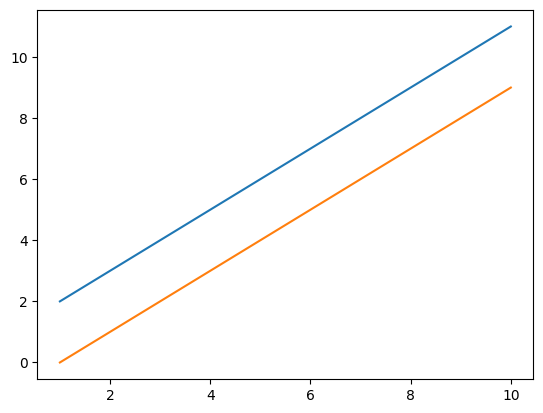

In [ ]:
plt.plot(pivot_tabla)

In [ ]:
df = StringIO(dataset_raw)
df = pd.read_csv(df)
df

,estudiante,aulasCategory,math_score,science_score
0,Estudiante_1,A,88,92
1,Estudiante_2,B,72,65
2,Estudiante_3,C,58,60
3,Estudiante_4,A,95,89
4,Estudiante_5,B,45,55
5,Estudiante_6,C,78,82
6,Estudiante_7,A,82,85
7,Estudiante_8,B,66,70
8,Estudiante_9,C,91,94
9,Estudiante_10,A,54,48


In [ ]:
promedio_Math = df.groupby('aulasCategory')['math_score'].mean().sort_values(ascending=False).round(2)
promedio_Math

,math_score
aulasCategory,
B,73.53
C,73.00
A,72.53


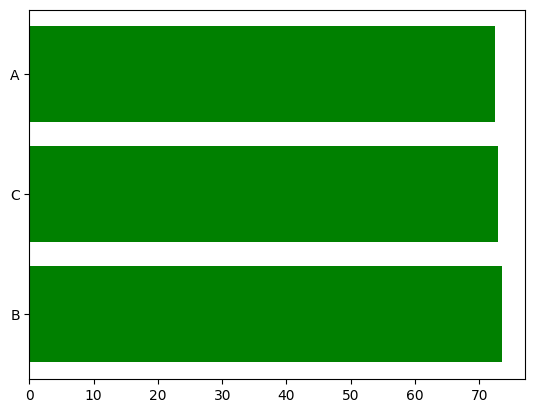

In [ ]:
from matplotlib import colors
#Creando la grafica en matplotlib
plt.barh(promedio_Math.index, promedio_Math.values, color= 'Green')
plt.show()

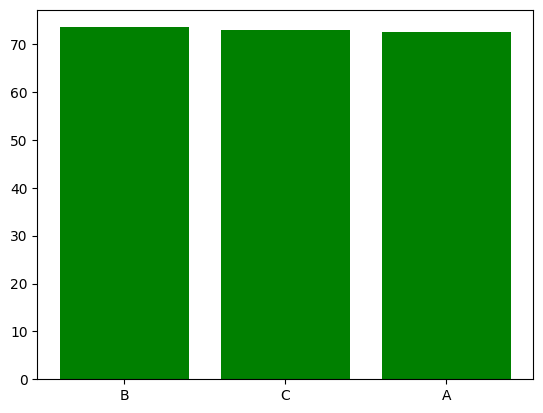

In [ ]:
plt.bar(promedio_Math.index, promedio_Math.values, color= 'Green')
plt.show()

<Axes: xlabel='math_score', ylabel='aulasCategory'>

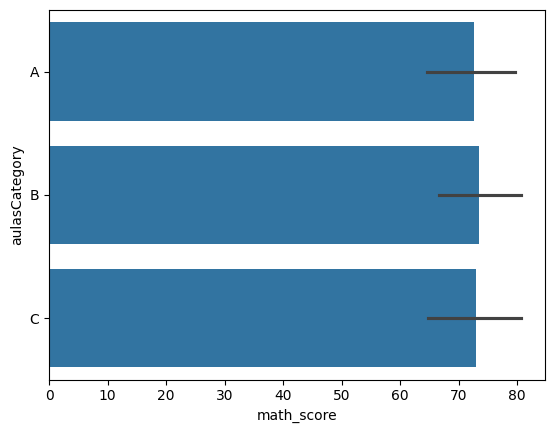

In [ ]:
#Trabajando con Seaborn
sns.barplot(x = 'math_score', y = 'aulasCategory', data = df, orient='h')

#Polars

In [ ]:
import polars as pl
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
products_data = {
    'product_id': range(1, 16),
    'product_name': [
        'Wireless Earbuds Pro', 'Smart Watch X', 'Gaming Laptop Elite',
        'Yoga Mat Premium', 'Blender Master 5000', 'Novel: The Silent Echo',
        'Coffee Maker Deluxe', 'Running Shoes Ultra', 'Python Data Science Cookbook',
        'Desk Lamp Modern', 'Tablet Pro 12"', 'Dumbbell Set 30kg',
        'World Cuisine Cookbook', '4-Slice Toaster', 'Wireless Mouse Ergo'
    ],
    'category': [
        'Electronics', 'Electronics', 'Electronics',
        'Sports & Fitness', 'Home & Kitchen', 'Books',
        'Home & Kitchen', 'Sports & Fitness', 'Books',
        'Home & Kitchen', 'Electronics', 'Sports & Fitness',
        'Books', 'Home & Kitchen', 'Electronics'
    ],
    'cost_price': [45.99, 120.50, 800.00, 15.99, 25.50, 8.99, 50.00, 70.00,
                    20.00, 12.99, 220.00, 45.00, 12.00, 18.50, 9.99],
    'selling_price': [79.99, 199.99, 1299.99, 29.99, 49.99, 14.99, 89.99,
                      119.99, 39.99, 24.99, 349.99, 89.99, 22.99, 34.99, 19.99],
    'stock_quantity': np.random.randint(10, 100, 15),
    'supplier': ['TechCorp', 'TechCorp', 'GameTech', 'FitLife', 'HomeGoods',
                 'BookWorld', 'HomeGoods', 'FitLife', 'BookWorld', 'HomeGoods',
                 'TechCorp', 'FitLife', 'BookWorld', 'HomeGoods', 'TechCorp']
}
df = pl.DataFrame(products_data)
df

product_id,product_name,category,cost_price,selling_price,stock_quantity,supplier
i64,str,str,f64,f64,i64,str
1,"""Wireless Earbuds Pro""","""Electronics""",45.99,79.99,66,"""TechCorp"""
2,"""Smart Watch X""","""Electronics""",120.5,199.99,15,"""TechCorp"""
3,"""Gaming Laptop Elite""","""Electronics""",800.0,1299.99,45,"""GameTech"""
4,"""Yoga Mat Premium""","""Sports & Fitness""",15.99,29.99,16,"""FitLife"""
5,"""Blender Master 5000""","""Home & Kitchen""",25.5,49.99,24,"""HomeGoods"""
…,…,…,…,…,…,…
11,"""Tablet Pro 12""""","""Electronics""",220.0,349.99,66,"""TechCorp"""
12,"""Dumbbell Set 30kg""","""Sports & Fitness""",45.0,89.99,16,"""FitLife"""
13,"""World Cuisine Cookbook""","""Books""",12.0,22.99,51,"""BookWorld"""


In [ ]:
#renonbrando las columnas
# df = df.rename({'product_id': 'ID', 'product_name': 'Product'})
df.columns = ['ID','Product_Name','Category','Cost_Price','Selling_Price','Stock_Quantity','Supplier']
df.columns

['ID',
 'Product_Name',
 'Category',
 'Cost_Price',
 'Selling_Price',
 'Stock_Quantity',
 'Supplier']

In [ ]:
#haciendo una consulta con polars
result = df.select(
    pl.col('ID'),
    pl.col('Product_Name'),
    pl.col('Category')
)
result

ID,Product_Name,Category
i64,str,str
1,"""Wireless Earbuds Pro""","""Electronics"""
2,"""Smart Watch X""","""Electronics"""
3,"""Gaming Laptop Elite""","""Electronics"""
4,"""Yoga Mat Premium""","""Sports & Fitness"""
5,"""Blender Master 5000""","""Home & Kitchen"""
…,…,…
11,"""Tablet Pro 12""""","""Electronics"""
12,"""Dumbbell Set 30kg""","""Sports & Fitness"""
13,"""World Cuisine Cookbook""","""Books"""


In [ ]:
#Agregando esos nuevos valores al dataframe existente
df = df.with_columns(
    Profit_Per_Order = pl.col('Selling_Price') - pl.col('Cost_Price')
)
df
#

ID,Product_Name,Category,Cost_Price,Selling_Price,Stock_Quantity,Supplier,Profit_Per_Order
i64,str,str,f64,f64,i64,str,f64
1,"""Wireless Earbuds Pro""","""Electronics""",45.99,79.99,66,"""TechCorp""",34.0
2,"""Smart Watch X""","""Electronics""",120.5,199.99,15,"""TechCorp""",79.49
3,"""Gaming Laptop Elite""","""Electronics""",800.0,1299.99,45,"""GameTech""",499.99
4,"""Yoga Mat Premium""","""Sports & Fitness""",15.99,29.99,16,"""FitLife""",14.0
5,"""Blender Master 5000""","""Home & Kitchen""",25.5,49.99,24,"""HomeGoods""",24.49
…,…,…,…,…,…,…,…
11,"""Tablet Pro 12""""","""Electronics""",220.0,349.99,66,"""TechCorp""",129.99
12,"""Dumbbell Set 30kg""","""Sports & Fitness""",45.0,89.99,16,"""FitLife""",44.99
13,"""World Cuisine Cookbook""","""Books""",12.0,22.99,51,"""BookWorld""",10.99


In [ ]:
#maneras de llamar a columnas y filas en polars
# df['Category'].head(2)
df.select('Category').head(2)


Category
str
"""Electronics"""
"""Electronics"""


In [ ]:
#Para poder filtara alguna fla con sus datos en polar no se usa el iloc entonces debemos usar el filter
resultado = df.filter(
    pl.col('Category') == 'Electronics'
)
resultado

ID,Product_Name,Category,Cost_Price,Selling_Price,Stock_Quantity,Supplier,Profit_Per_Order
i64,str,str,f64,f64,i64,str,f64
1,"""Wireless Earbuds Pro""","""Electronics""",45.99,79.99,66,"""TechCorp""",34.0
2,"""Smart Watch X""","""Electronics""",120.5,199.99,15,"""TechCorp""",79.49
3,"""Gaming Laptop Elite""","""Electronics""",800.0,1299.99,45,"""GameTech""",499.99
11,"""Tablet Pro 12""""","""Electronics""",220.0,349.99,66,"""TechCorp""",129.99
15,"""Wireless Mouse Ergo""","""Electronics""",9.99,19.99,85,"""TechCorp""",10.0


In [ ]:
#otro metodo de filtado es el slicing
df[:4: 2]

ID,Product_Name,Category,Cost_Price,Selling_Price,Stock_Quantity,Supplier,Profit_Per_Order
i64,str,str,f64,f64,i64,str,f64
1,"""Wireless Earbuds Pro""","""Electronics""",45.99,79.99,66,"""TechCorp""",34.0
3,"""Gaming Laptop Elite""","""Electronics""",800.0,1299.99,45,"""GameTech""",499.99


In [ ]:
campaigns_data = {
    'campaign_id': range(1, 11),
    'campaign_name': [
        'Spring Sale 2023', 'Back to School', 'Black Friday', 'Cyber Monday',
        'Holiday Special 2023', 'New Year Clearance', 'Valentine\'s Day',
        'Summer Blowout', 'Tech Week', 'Year-End Sale 2024'
    ],
    'start_date': [
        '2023-03-20', '2023-08-15', '2023-11-24', '2023-11-27',
        '2023-12-15', '2024-01-01', '2024-02-01', '2024-06-15',
        '2024-09-10', '2024-11-20'
    ],
    'end_date': [
        '2023-04-05', '2023-09-05', '2023-11-26', '2023-11-28',
        '2023-12-31', '2024-01-31', '2024-02-14', '2024-07-15',
        '2024-09-17', '2024-12-15'
    ],
    'discount_percent': [15, 10, 30, 25, 20, 15, 10, 25, 20, 30],
    'channel': ['Email', 'Social Media', 'Email', 'Social Media',
                'Email', 'Email', 'Social Media', 'Email', 'Social Media', 'Email']
}
data = pl.DataFrame(campaigns_data)


In [ ]:
data


campaign_id,campaign_name,start_date,end_date,discount_percent,channel
i64,str,str,str,i64,str
1,"""Spring Sale 2023""","""2023-03-20""","""2023-04-05""",15,"""Email"""
2,"""Back to School""","""2023-08-15""","""2023-09-05""",10,"""Social Media"""
3,"""Black Friday""","""2023-11-24""","""2023-11-26""",30,"""Email"""
4,"""Cyber Monday""","""2023-11-27""","""2023-11-28""",25,"""Social Media"""
5,"""Holiday Special 2023""","""2023-12-15""","""2023-12-31""",20,"""Email"""
6,"""New Year Clearance""","""2024-01-01""","""2024-01-31""",15,"""Email"""
7,"""Valentine's Day""","""2024-02-01""","""2024-02-14""",10,"""Social Media"""
8,"""Summer Blowout""","""2024-06-15""","""2024-07-15""",25,"""Email"""
9,"""Tech Week""","""2024-09-10""","""2024-09-17""",20,"""Social Media"""


In [ ]:
data = data.with_columns(
    pl.col("start_date").str.strptime(pl.Date, format="%Y-%m-%d"),
    pl.col("end_date").str.strptime(pl.Date, format="%Y-%m-%d"),
)
data

campaign_id,campaign_name,start_date,end_date,discount_percent,channel
i64,str,date,date,i64,str
1,"""Spring Sale 2023""",2023-03-20,2023-04-05,15,"""Email"""
2,"""Back to School""",2023-08-15,2023-09-05,10,"""Social Media"""
3,"""Black Friday""",2023-11-24,2023-11-26,30,"""Email"""
4,"""Cyber Monday""",2023-11-27,2023-11-28,25,"""Social Media"""
5,"""Holiday Special 2023""",2023-12-15,2023-12-31,20,"""Email"""
6,"""New Year Clearance""",2024-01-01,2024-01-31,15,"""Email"""
7,"""Valentine's Day""",2024-02-01,2024-02-14,10,"""Social Media"""
8,"""Summer Blowout""",2024-06-15,2024-07-15,25,"""Email"""
9,"""Tech Week""",2024-09-10,2024-09-17,20,"""Social Media"""


In [ ]:
filtro2024 = data.filter(
    pl.col('start_date').dt.year() == 2024
)
filtro2024

campaign_id,campaign_name,start_date,end_date,discount_percent,channel
i64,str,date,date,i64,str
6,"""New Year Clearance""",2024-01-01,2024-01-31,15,"""Email"""
7,"""Valentine's Day""",2024-02-01,2024-02-14,10,"""Social Media"""
8,"""Summer Blowout""",2024-06-15,2024-07-15,25,"""Email"""
9,"""Tech Week""",2024-09-10,2024-09-17,20,"""Social Media"""
10,"""Year-End Sale 2024""",2024-11-20,2024-12-15,30,"""Email"""


In [ ]:
filtro2024.group_by(
    pl.col('channel').alias('Llegada'),
    maintain_order = True
).len()


Llegada,len
str,u32
"""Email""",3
"""Social Media""",2


In [ ]:
filtro_23_24 = data.filter(
    pl.col('start_date').dt.year().is_between(2023, 2024).alias('Grupo23-24'),
    pl.col('channel').is_in(['Email']).alias('GrupoEmail'),
    pl.col('discount_percent') > 15
)
filtro_23_24

campaign_id,campaign_name,start_date,end_date,discount_percent,channel
i64,str,date,date,i64,str
3,"""Black Friday""",2023-11-24,2023-11-26,30,"""Email"""
5,"""Holiday Special 2023""",2023-12-15,2023-12-31,20,"""Email"""
8,"""Summer Blowout""",2024-06-15,2024-07-15,25,"""Email"""
10,"""Year-End Sale 2024""",2024-11-20,2024-12-15,30,"""Email"""


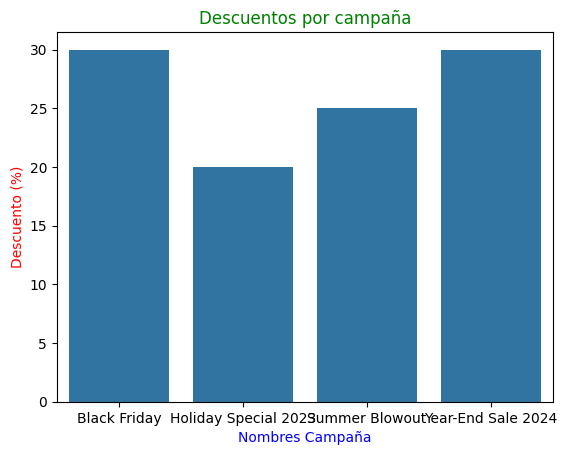

In [ ]:
sns.barplot(x = 'campaign_name', y = 'discount_percent', data = filtro_23_24)
plt.title('Descuentos por campaña', color = 'Green')
plt.xlabel('Nombres Campaña', color = 'blue')
plt.ylabel('Descuento (%)', color = 'red')
plt.show()
#

In [ ]:
#concatenacion
datos_contacto1 = pl.DataFrame({
    'id': [4, 5, 7],
    'email': ['pedro@mail.com', 'jose@mail.com', 'manuel@mail.com']
})
datos_contacto2 = pl.DataFrame({
    'id': [1, 2, 4],
    'email': ['ana@mail.com', 'luis@mail.com', 'carlos@mail.com']
})

#

In [ ]:
data1 = pl.concat([datos_contacto1, datos_contacto2], how = 'vertical')
data1

id,email
i64,str
4,"""pedro@mail.com"""
5,"""jose@mail.com"""
7,"""manuel@mail.com"""
1,"""ana@mail.com"""
2,"""luis@mail.com"""
4,"""carlos@mail.com"""


In [ ]:
datos_contacto1 = pl.DataFrame({
    'id': [4, 5, 7],
    'email': ['pedro@mail.com', 'jose@mail.com', 'manuel@mail.com']
})
datos_contacto2 = pl.DataFrame({
    'deID': [1, 2, 4],
    'subcorrreo': ['ana@mail.com', 'luis@mail.com', 'carlos@mail.com']
})
datosJuntos = pl.concat([datos_contacto1, datos_contacto2], how = 'horizontal')
datosJuntos

id,email,deID,subcorrreo
i64,str,i64,str
4,"""pedro@mail.com""",1,"""ana@mail.com"""
5,"""jose@mail.com""",2,"""luis@mail.com"""
7,"""manuel@mail.com""",4,"""carlos@mail.com"""


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl

In [ ]:
data = {
    'name': ['John', 'Jane', 'Mike', 'Sarah', 'Aaron', 'Peter'],
    'age': [25, 30, 35, 67, 27, 28],
    'city': ['New York', 'San Francisco', 'Los Angeles', 'Chicago', 'New York', 'New York']
}
df = pd.DataFrame(data)
df.head(6)
pct_values = (df['city'].value_counts(normalize=True) * 100).round(2)
pct_values

,proportion
city,
New York,50.00
San Francisco,16.67
Los Angeles,16.67
Chicago,16.67


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

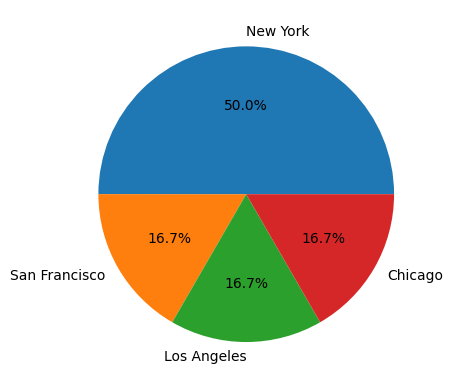

In [ ]:
plt.pie(pct_values, labels=pct_values.index, autopct='%1.1f%%')
plt

#ejercicios pandas


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
dataframe = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Dataset_Empresa_Fabricante_de_Algodón.csv', encoding='Latin 1')

In [ ]:
# EJERCICIO 5: Window Functions: Control de Calidad
# Título: Identificación de Desempeño Atípico en Defectos.
# Descripción: Ordena el DF por 'ID_Pedido'. Calcula el promedio móvil (rolling mean) \
# de 'Defectos_Unidad' con una ventana de 5. Luego, identifica qué pedidos tienen \
# defectos al menos 2 veces por encima de ese promedio móvil.
dataframe.head()

,ID_Pedido,Fecha_Pedido,Cliente_ID,Pais,Region,Producto_ID,Categoria_Producto,Unidades_Vendidas,Precio_Unitario_USD,Costo_Produccion_Unitario_USD,...,Agua_Utilizada_L,Energia_Consumida_kWh,Fecha_Produccion,Turno_Produccion,Defectos_Unidad,Rechazos_Calidad,Ventas_Totales_USD,Costos_Totales_USD,Beneficio_USD,Margen_Beneficio
0,1001,1/5/2024,CL20345,Estados Unidos,Norte América,PRD001,Tela Cruda,1500,12.50,7.20,...,950000,18500,1/10/2024,Diurno,15,8,18750.0,10800.0,7950.0,42.4
1,1002,1/7/2024,CL11022,Mexico,Latino América,PRD003,Tela Teñida,800,18.75,10.50,...,520000,9800,1/12/2024,Nocturno,8,3,15000.0,8400.0,6600.0,44.0
2,1003,1/8/2024,CL30567,España,Europa,PRD005,Hilado,2500,8.90,4.75,...,1500000,32000,1/9/2024,Diurno,32,18,22250.0,11875.0,10375.0,46.6
3,1004,1/10/2024,CL40981,Brasil,Latino América,PRD002,Tela Cruda,1200,13.25,7.80,...,760000,14800,1/15/2024,Diurno,10,5,15900.0,9360.0,6540.0,41.1
4,1005,1/12/2024,CL50234,India,Asia,PRD004,Tela Estampada,950,22.40,13.20,...,610000,11500,1/18/2024,Nocturno,12,6,21280.0,12540.0,8740.0,41.1


In [ ]:
dataframe_sorted = dataframe.sort_values('ID_Pedido').copy()

In [ ]:
dataframe_sorted.head()
dataframe_sorted['Promedio_Movil'] = dataframe_sorted['Defectos_Unidad'].rolling(window=5, min_periods = 1).mean().round(2)
dataframe_sorted[['ID_Pedido', 'Defectos_Unidad', 'Promedio_Movil']].head()

,ID_Pedido,Defectos_Unidad,Promedio_Movil
0,1001,15,15.00
1,1002,8,11.50
2,1003,32,18.33
3,1004,10,16.25
4,1005,12,15.40


In [ ]:
dataframe_sorted['Atipico'] = dataframe_sorted['Defectos_Unidad'] >= (2 * dataframe_sorted['Promedio_Movil'])


In [ ]:
dataframe_sorted.loc[dataframe_sorted['Atipico'] == True]

,ID_Pedido,Fecha_Pedido,Cliente_ID,Pais,Region,Producto_ID,Categoria_Producto,Unidades_Vendidas,Precio_Unitario_USD,Costo_Produccion_Unitario_USD,...,Fecha_Produccion,Turno_Produccion,Defectos_Unidad,Rechazos_Calidad,Ventas_Totales_USD,Costos_Totales_USD,Beneficio_USD,Margen_Beneficio,Promedio_Movil,Atipico
27,1028,3/15/2024,CL30567,España,Europa,PRD006,Hilado,3400,9.1,5.1,...,3/18/2024,Nocturno,34,17,30940.0,17340.0,13600.0,44.0,16.2,True
47,1048,5/6/2024,CL50234,India,Asia,PRD006,Hilado,3300,9.1,5.1,...,5/10/2024,Nocturno,33,16,30030.0,16830.0,13200.0,44.0,15.2,True


<Axes: xlabel='ID_Pedido'>

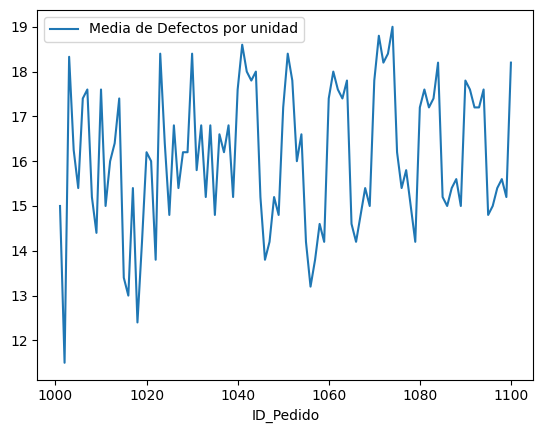

In [ ]:
dataframe_sorted.plot.line(x = 'ID_Pedido', y='Promedio_Movil', label = 'Media de Defectos por unidad')

In [ ]:
dataframe.head()
dataframe['Moving Average'] = dataframe['Defectos_Unidad'].rolling(window=5).mean()
dataframe.head(10)

,ID_Pedido,Fecha_Pedido,Cliente_ID,Pais,Region,Producto_ID,Categoria_Producto,Unidades_Vendidas,Precio_Unitario_USD,Costo_Produccion_Unitario_USD,...,Energia_Consumida_kWh,Fecha_Produccion,Turno_Produccion,Defectos_Unidad,Rechazos_Calidad,Ventas_Totales_USD,Costos_Totales_USD,Beneficio_USD,Margen_Beneficio,Moving Average
0,1001,1/5/2024,CL20345,Estados Unidos,Norte América,PRD001,Tela Cruda,1500,12.50,7.20,...,18500,1/10/2024,Diurno,15,8,18750.0,10800.0,7950.0,42.4,NaN
1,1002,1/7/2024,CL11022,Mexico,Latino América,PRD003,Tela Teñida,800,18.75,10.50,...,9800,1/12/2024,Nocturno,8,3,15000.0,8400.0,6600.0,44.0,NaN
2,1003,1/8/2024,CL30567,España,Europa,PRD005,Hilado,2500,8.90,4.75,...,32000,1/9/2024,Diurno,32,18,22250.0,11875.0,10375.0,46.6,NaN
3,1004,1/10/2024,CL40981,Brasil,Latino América,PRD002,Tela Cruda,1200,13.25,7.80,...,14800,1/15/2024,Diurno,10,5,15900.0,9360.0,6540.0,41.1,NaN
4,1005,1/12/2024,CL50234,India,Asia,PRD004,Tela Estampada,950,22.40,13.20,...,11500,1/18/2024,Nocturno,12,6,21280.0,12540.0,8740.0,41.1,15.4
5,1006,1/15/2024,CL60115,Francia,Europa,PRD006,Hilado,3000,9.10,5.10,...,38500,1/18/2024,Diurno,25,12,27300.0,15300.0,12000.0,44.0,17.4
6,1007,1/18/2024,CL20345,Estados Unidos,Norte América,PRD007,Tela Teñida,700,19.50,11.25,...,8700,1/22/2024,Nocturno,9,4,13650.0,7875.0,5775.0,42.3,17.6
7,1008,1/20/2024,CL71002,Egipto,África,PRD001,Tela Cruda,1800,12.50,7.20,...,22200,1/25/2024,Diurno,20,11,22500.0,12960.0,9540.0,42.4,15.2
8,1009,1/22/2024,CL81056,Japón,Asia,PRD008,Tela Estampada,600,24.30,14.80,...,7400,1/26/2024,Nocturno,6,2,14580.0,8880.0,5700.0,39.1,14.4
9,1010,1/25/2024,CL30567,España,Europa,PRD009,Hilado,2200,8.50,4.60,...,28200,1/28/2024,Diurno,28,15,18700.0,10120.0,8580.0,45.9,17.6


<Axes: xlabel='ID_Pedido'>

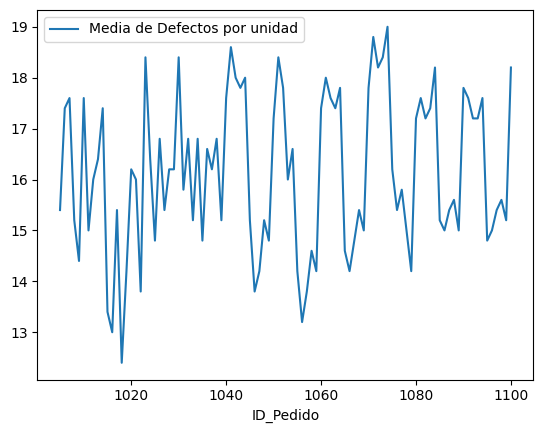

In [ ]:
dataframe.plot.line(x = 'ID_Pedido', y= 'Moving Average', label = 'Media de Defectos por unidad')

<Axes: xlabel='ID_Pedido'>

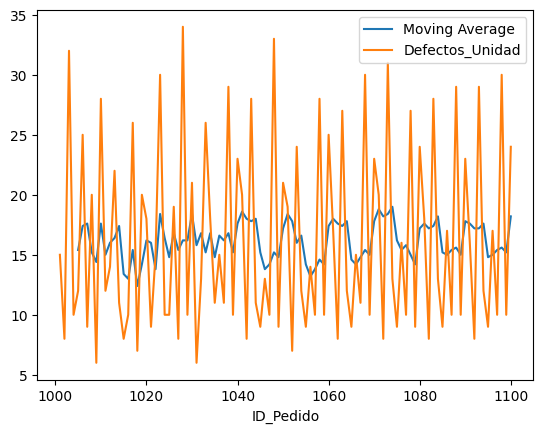

In [ ]:
dataframe.plot.line(x = 'ID_Pedido', y= ['Moving Average', 'Defectos_Unidad'])

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATASETS/Dataset_Empresa_Fabricante_de_Algodón.csv', encoding='latin1')
df.head(50)

,ID_Pedido,Fecha_Pedido,Cliente_ID,Pais,Region,Producto_ID,Categoria_Producto,Unidades_Vendidas,Precio_Unitario_USD,Costo_Produccion_Unitario_USD,...,Agua_Utilizada_L,Energia_Consumida_kWh,Fecha_Produccion,Turno_Produccion,Defectos_Unidad,Rechazos_Calidad,Ventas_Totales_USD,Costos_Totales_USD,Beneficio_USD,Margen_Beneficio
0,1001,1/5/2024,CL20345,Estados Unidos,Norte América,PRD001,Tela Cruda,1500,12.50,7.20,...,950000,18500,1/10/2024,Diurno,15,8,18750.0,10800.0,7950.0,42.4
1,1002,1/7/2024,CL11022,Mexico,Latino América,PRD003,Tela Teñida,800,18.75,10.50,...,520000,9800,1/12/2024,Nocturno,8,3,15000.0,8400.0,6600.0,44.0
2,1003,1/8/2024,CL30567,España,Europa,PRD005,Hilado,2500,8.90,4.75,...,1500000,32000,1/9/2024,Diurno,32,18,22250.0,11875.0,10375.0,46.6
3,1004,1/10/2024,CL40981,Brasil,Latino América,PRD002,Tela Cruda,1200,13.25,7.80,...,760000,14800,1/15/2024,Diurno,10,5,15900.0,9360.0,6540.0,41.1
4,1005,1/12/2024,CL50234,India,Asia,PRD004,Tela Estampada,950,22.40,13.20,...,610000,11500,1/18/2024,Nocturno,12,6,21280.0,12540.0,8740.0,41.1
5,1006,1/15/2024,CL60115,Francia,Europa,PRD006,Hilado,3000,9.10,5.10,...,1800000,38500,1/18/2024,Diurno,25,12,27300.0,15300.0,12000.0,44.0
6,1007,1/18/2024,CL20345,Estados Unidos,Norte América,PRD007,Tela Teñida,700,19.50,11.25,...,460000,8700,1/22/2024,Nocturno,9,4,13650.0,7875.0,5775.0,42.3
7,1008,1/20/2024,CL71002,Egipto,África,PRD001,Tela Cruda,1800,12.50,7.20,...,1140000,22200,1/25/2024,Diurno,20,11,22500.0,12960.0,9540.0,42.4
8,1009,1/22/2024,CL81056,Japón,Asia,PRD008,Tela Estampada,600,24.30,14.80,...,390000,7400,1/26/2024,Nocturno,6,2,14580.0,8880.0,5700.0,39.1
9,1010,1/25/2024,CL30567,España,Europa,PRD009,Hilado,2200,8.50,4.60,...,1320000,28200,1/28/2024,Diurno,28,15,18700.0,10120.0,8580.0,45.9


Text(0.5, 0, 'ID De los pedidios')

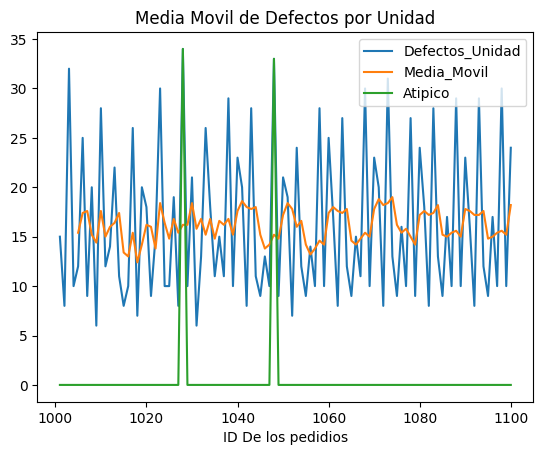

In [ ]:
## EJERCICIO 5: Window Functions: Control de Calidad -- Media Movil-- Rolling.mean(window = 5)
# Título: Identificación de Desempeño Atípico en Defectos.
# Descripción: Ordena el DF por 'ID_Pedido'. Calcula el promedio móvil (rolling mean)
# de 'Defectos_Unidad' con una ventana de 5. Luego, identifica qué pedidos tienen
# defectos al menos 2 veces por encima de ese promedio móvil.
# df['Defectos_Unidad']
Sorted_df = df.sort_values(by ='ID_Pedido')
Sorted_df['Media_Movil'] = Sorted_df['Defectos_Unidad'].rolling(window = 5).mean().round(2)
Sorted_df.head(25)[['Defectos_Unidad', 'Media_Movil']]
Sorted_df['Atipico'] = np.where(Sorted_df['Defectos_Unidad'] >= (Sorted_df["Media_Movil"]*2), Sorted_df['Defectos_Unidad'], 0)
Sorted_df[['Defectos_Unidad', 'Media_Movil', 'Atipico']]
Sorted_df.plot.line(y = ['Defectos_Unidad','Media_Movil', 'Atipico'], x = 'ID_Pedido')
plt.title('Media Movil de Defectos por Unidad')
plt.xlabel('ID De los pedidios')



In [ ]:
# EJERCICIO 7: Advanced Aggregation: Costo por Unidad de Materia Prima
# Título: Costo Promedio Ponderado de Materia Prima.
# Descripción: Calcula la media PONDERADA del Costo_Produccion_Unitario_USD utilizando
# Materia_Prima_Kg como peso. Haz este cálculo agrupado por 'Categoria_Producto'.

def promedioponderado(dset):
  return (np.average(dset['Costo_Produccion_Unitario_USD'],
                     weights=dset['Materia_Prima_Kg']).round(2))

df.groupby('Categoria_Producto').apply(promedioponderado)



/tmp/ipython-input-1327775913.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('Categoria_Producto').apply(promedioponderado)


,0
Categoria_Producto,
Hilado,4.85
Tela Cruda,7.42
Tela Estampada,13.86
Tela Teñida,10.83


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_Pedido                      100 non-null    int64  
 1   Fecha_Pedido                   100 non-null    object 
 2   Cliente_ID                     100 non-null    object 
 3   Pais                           100 non-null    object 
 4   Region                         100 non-null    object 
 5   Producto_ID                    100 non-null    object 
 6   Categoria_Producto             100 non-null    object 
 7   Unidades_Vendidas              100 non-null    int64  
 8   Precio_Unitario_USD            100 non-null    float64
 9   Costo_Produccion_Unitario_USD  100 non-null    float64
 10  Metodo_Produccion              100 non-null    object 
 11  Calidad_Algodon                100 non-null    object 
 12  Sostenibilidad_Certificada     100 non-null    bool

In [ ]:
# EJERCICIO 9: Logistical Analysis: Retraso en la Entrega
# Título: Impacto del Retraso en la Satisfacción.
# Descripción: Crea una columna booleana 'Retraso' (True si Fecha_Produccion - Fecha_Pedido > Plazo_Entrega_Dias).
# Calcula la satisfacción promedio (ignora nulos) para pedidos con Retraso=True vs. Retraso=False.

df['fecha_pedido'] = pd.to_datetime(df['Fecha_Pedido'])
df['fecha_produccion'] = pd.to_datetime(df['Fecha_Produccion'])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   ID_Pedido                      100 non-null    int64         
 1   Fecha_Pedido                   100 non-null    object        
 2   Cliente_ID                     100 non-null    object        
 3   Pais                           100 non-null    object        
 4   Region                         100 non-null    object        
 5   Producto_ID                    100 non-null    object        
 6   Categoria_Producto             100 non-null    object        
 7   Unidades_Vendidas              100 non-null    int64         
 8   Precio_Unitario_USD            100 non-null    float64       
 9   Costo_Produccion_Unitario_USD  100 non-null    float64       
 10  Metodo_Produccion              100 non-null    object        
 11  Calidad_Algodon     

In [ ]:
# df['Retraso'] = (df['Fecha_Produccion'] - df['Fecha_Pedido']).dt.days > df['Plazo_Entrega_Dias']
# df['Retraso'].head(14)
df['Fecha_Pedido'] = pd.to_datetime(df['Fecha_Pedido'])
Ganancias_Por_Mes = df.groupby(df['Fecha_Pedido'].dt.month_name())['Ventas_Totales_USD'].sum()
Ganancias_Por_Mes = Ganancias_Por_Mes.reset_index()

Ganancias_Por_Mes

,Fecha_Pedido,Ventas_Totales_USD
0,April,222885.5
1,August,260872.5
2,February,206240.0
3,January,210535.0
4,July,248890.0
5,June,253582.0
6,March,240649.5
7,May,236251.0
8,September,132078.5


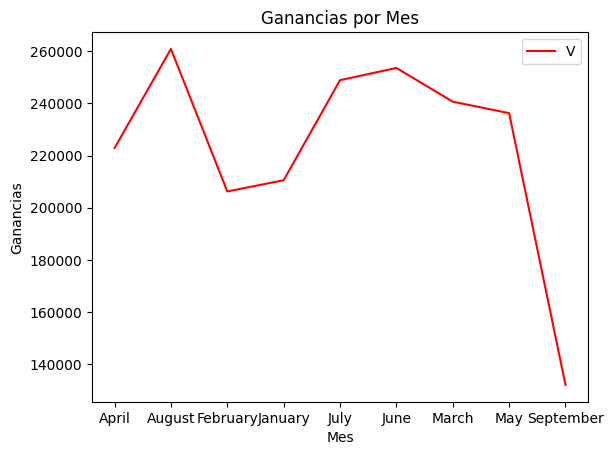

In [ ]:
plt.plot(Ganancias_Por_Mes['Fecha_Pedido'] , Ganancias_Por_Mes['Ventas_Totales_USD'], color = 'red')
plt.title('Ganancias por Mes')
plt.xlabel('Mes')
plt.legend('Ventas Totales')
plt.ylabel('Ganancias')
plt.show()

In [ ]:
Mes_Mayor_Ganancia = Ganancias_Por_Mes.groupby('Fecha_Pedido')['Ventas_Totales_USD'].sum()
Mes_Mayor_Ganancia = Mes_Mayor_Ganancia.reset_index()
Mayor = Mes_Mayor_Ganancia['Ventas_Totales_USD'].max()
Mes_Mayor_Ganancia[Mes_Mayor_Ganancia['Ventas_Totales_USD'] == Mayor]
# Mes_Mayor_Ganancia['Ventas_Totales_USD'].max_index()


,Fecha_Pedido,Ventas_Totales_USD
1,August,260872.5


In [ ]:
df.head()

,ID_Pedido,Fecha_Pedido,Cliente_ID,Pais,Region,Producto_ID,Categoria_Producto,Unidades_Vendidas,Precio_Unitario_USD,Costo_Produccion_Unitario_USD,...,Fecha_Produccion,Turno_Produccion,Defectos_Unidad,Rechazos_Calidad,Ventas_Totales_USD,Costos_Totales_USD,Beneficio_USD,Margen_Beneficio,fecha_pedido,fecha_produccion
0,1001,2024-01-05,CL20345,Estados Unidos,Norte América,PRD001,Tela Cruda,1500,12.50,7.20,...,1/10/2024,Diurno,15,8,18750.0,10800.0,7950.0,42.4,2024-01-05,2024-01-10
1,1002,2024-01-07,CL11022,Mexico,Latino América,PRD003,Tela Teñida,800,18.75,10.50,...,1/12/2024,Nocturno,8,3,15000.0,8400.0,6600.0,44.0,2024-01-07,2024-01-12
2,1003,2024-01-08,CL30567,España,Europa,PRD005,Hilado,2500,8.90,4.75,...,1/9/2024,Diurno,32,18,22250.0,11875.0,10375.0,46.6,2024-01-08,2024-01-09
3,1004,2024-01-10,CL40981,Brasil,Latino América,PRD002,Tela Cruda,1200,13.25,7.80,...,1/15/2024,Diurno,10,5,15900.0,9360.0,6540.0,41.1,2024-01-10,2024-01-15
4,1005,2024-01-12,CL50234,India,Asia,PRD004,Tela Estampada,950,22.40,13.20,...,1/18/2024,Nocturno,12,6,21280.0,12540.0,8740.0,41.1,2024-01-12,2024-01-18


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   ID_Pedido                      100 non-null    int64         
 1   Fecha_Pedido                   100 non-null    datetime64[ns]
 2   Cliente_ID                     100 non-null    object        
 3   Pais                           100 non-null    object        
 4   Region                         100 non-null    object        
 5   Producto_ID                    100 non-null    object        
 6   Categoria_Producto             100 non-null    object        
 7   Unidades_Vendidas              100 non-null    int64         
 8   Precio_Unitario_USD            100 non-null    float64       
 9   Costo_Produccion_Unitario_USD  100 non-null    float64       
 10  Metodo_Produccion              100 non-null    object        
 11  Calidad_Algodon     

In [ ]:
Ventas_Totales_Acumuladas = df['Ventas_Totales_USD'].sum()
Ventas_Totales_Acumuladas

np.float64(2011984.0)

In [ ]:
Ventas_Por_Region = df.groupby('Region')['Ventas_Totales_USD'].sum()
Ventas_Por_Region

,Ventas_Totales_USD
Region,
Asia,240192.0
Europa,457777.5
Latino América,399038.0
Norte América,441766.0
Oceanía,235110.5
África,238100.0
